<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/tugas1Jobsheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


In [4]:
df = pd.read_csv("Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [6]:
df.columns = df.columns.str.strip()

# hapus baris yang memiliki missing value pada atribut label (Life expectancy)
df = df.dropna(subset=['Life expectancy'])

# pilih atribut numerik yang berpengaruh (Feature Selection)
selected_columns = ['Life expectancy', 'Adult Mortality', 'Schooling', 'GDP', 'BMI', 'HIV/AIDS', 'Income composition of resources']
df = df[selected_columns]

# isi missing values pada atribut prediktor dengan nilai rata-rata
df = df.fillna(df.mean())

In [14]:
# menggunakan semua atribut prediktor yang dipilih untuk X
X = df[['Adult Mortality', 'Schooling', 'GDP', 'BMI', 'HIV/AIDS', 'Income composition of resources']]
y = df['Life expectancy']

In [15]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

Intercept: 55.58168601971079
Slope: [-2.23904575e-02  8.93180561e-01  5.50551097e-05  6.38932009e-02
 -4.87312567e-01  7.33664559e+00]


In [17]:
y_pred = model.predict(X_test)

# hitung RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Square Error (RMSE):", rmse)

Root Mean Square Error (RMSE): 4.303051258142992


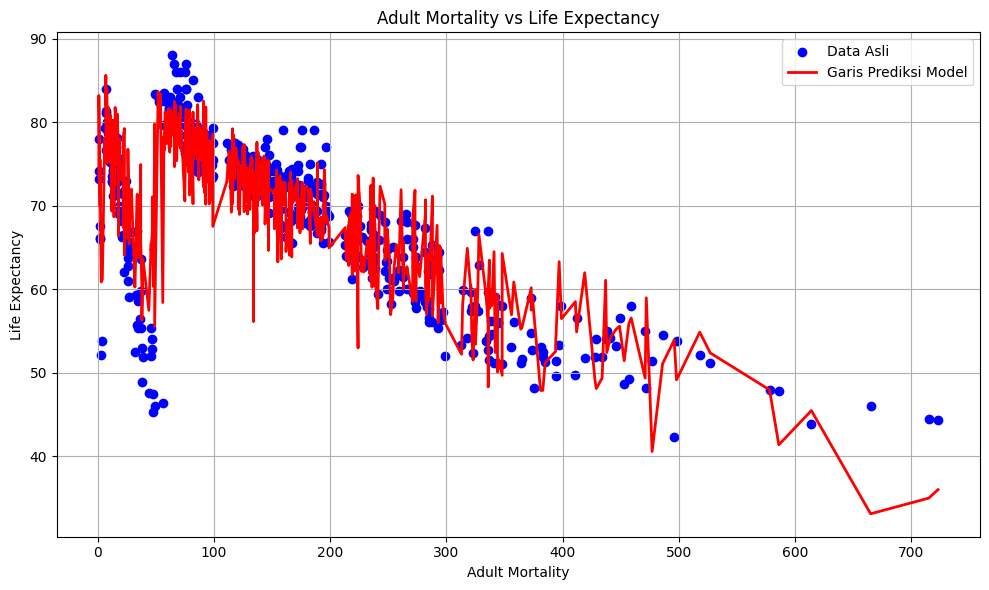

In [21]:
feature_to_visualize = 'Adult Mortality'

x_plot = X_test[feature_to_visualize]

plt.figure(figsize=(10, 6))
# scatter plot data asli
plt.scatter(x_plot, y_test, color='blue', label='Data Asli')

sorted_indices = np.argsort(x_plot.values)

x_plot_sorted = x_plot.iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.plot(x_plot_sorted, y_pred_sorted, color='red', linewidth=2, label='Garis Prediksi Model')

plt.xlabel(feature_to_visualize)
plt.ylabel("Life Expectancy")
plt.title(f"{feature_to_visualize} vs Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()